# **Support Vector Machine** (Sesi 17-18, 5 May 2026)

Fadhlan Nur Rachman (2802491960)

Data Dictionary :
- survival:	Survival	0 = No, 1 = Yes
- pclass:	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
- sex:	Sex
- Age:	Age in years
- sibsp	# of siblings / spouses aboard the Titanic
- parch	# of parents / children aboard the Titanic
- ticket:	Ticket number
- fare:	Passenger fare
- cabin:	Cabin number
- embarked:	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

In [39]:
# Import Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv('titanic/train.csv')

In [40]:
train_data.shape

(891, 12)

**Interpretasi cell diatas**:  
terdapat data train sebanyak (891 baris dan 12 fitur) termasuk dengan 1 fitur target


In [41]:
# Preview Dataset
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:
# Drop Unnecessary Columns
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

train_data = train_data.drop(columns=cols_to_drop)
train_data.shape

(891, 8)

**Interpretasi cell diatas**:  
PassengerId, Name, Ticket, dan Cabin dihapus karena variable ini bertipe string dengan unique value yang tinggi atau memiliki banyak data hilang, sehingga data tersebut tidak bisa memberikan pola statistik

# Exploratory Data Analysis

In [43]:
# Check head
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


**Interpretasi cell diatas**:  
Hasil data train setelah menghapus variable PassengerId, Name, Ticket, dan Cabin


In [44]:
# Identifying Data Structure

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


**Interpretasi cell diatas**:  
cek informasi dari data train terdapat info tipedata dari setiap variable ada 2 float, 4 integer, dan 2 object atau kategorikal data. serta terdapat banyaknya baris yang memiliki isi dari setiap variable nya. dan disini kita bisa mengetahui data lengkap seluruhnya terisi ada 891 dan jika ada variable yang tidak 891 berarti ada missing value


In [45]:
# Summary Statistics for Numerical Columns

train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Interpretasi cell diatas**:  
terdapat hasil statistik data numerical yang bisa menunjukkan distribusi serta kesimpulan dari setiap data nya dan bisa jadi insight untuk kita seperti contoh "rata-rata umur penumpang adalah sekitar 29.7 tahun" lalu ada "tarif(Fare) memiliki standar deviasi yang sangat tinggi 49.69 yang menunjukan adanya kesenjangan harga tiket yang lebar" dan berbagai informasi menarik lainnya


In [46]:
# Summary Statistics for Categorical Columns

train_data.describe(include=['O'])

,Sex,Embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Interpretasi cell diatas**:  
terdapat hasil statistik data kategorikal yang menunjukan distribusi jumlah penumpang berdasarkan jenis kelamin(Sex) dan pelabuhan keberangkatan(Embarked). dan ada juga mayoritas seperti penumpang banyak yang naik dari pelabuhan 'S' (Southampton) dan jenis kelamin terbanyak jatuh kepada lelaki dengan frekuensi muncul sebanyak 577

In [47]:
# Percentage of Missing Values

missing_summary = pd.DataFrame({
    'Missing Count': train_data.isnull().sum(),
    'Missing Percentage(%)': (train_data.isnull().mean() * 100).round(2)
})
missing_summary

,Missing Count,Missing Percentage(%)
Survived,0,0.00
Pclass,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Fare,0,0.00
Embarked,2,0.22


**Interpretasi cell diatas**:  
Melihat sebuah missing value yang lebih lengkap dimana ternyata terdapat sebuah persentase yang menunjukan 19.86% data umur(Age) ada baris yang hilang serta 0.22% pelabuhan keberangkatan(Embarked) ada baris yang hilang juga

In [48]:
# Cross Tabulation

sex_embarked_ct = pd.crosstab(train_data['Sex'], train_data['Embarked'], dropna=False)

sex_embarked_ct

Embarked,C,Q,S,NaN
Sex,,,,
female,73,36,203,2
male,95,41,441,0


**Interpretasi cell diatas**:  
Menunjukkan distribusi jumlah penumpang berdasarkan jenis kelamin dan pelabuhan keberangkatan. Mayoritas penumpang naik dari pelabuhan 'S' (Southampton) dan sebagai contoh informasi "di pelabuhan southampton terdapat 203 penumpang perempuan yang naik ke kapal"

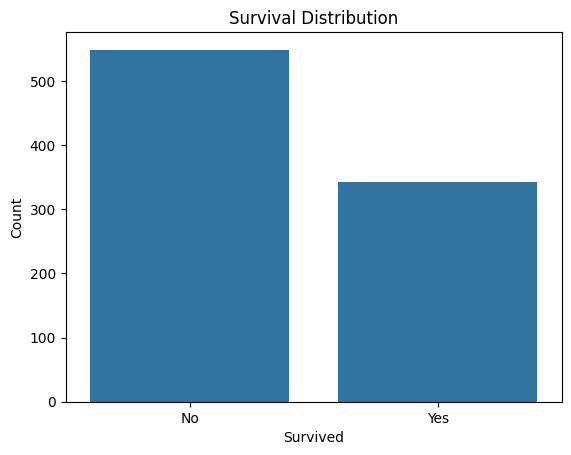

In [49]:
# Bar Plot Survival Distribution

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Survived', data=train_data)
plt.title('Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

**Interpretasi cell diatas**:  
Terlihat Data target tidak seimbang. jumlah penumpang yang tidak selamat(survived = 0) jauh lebih banyak daripada yang selamat(survived = 1)

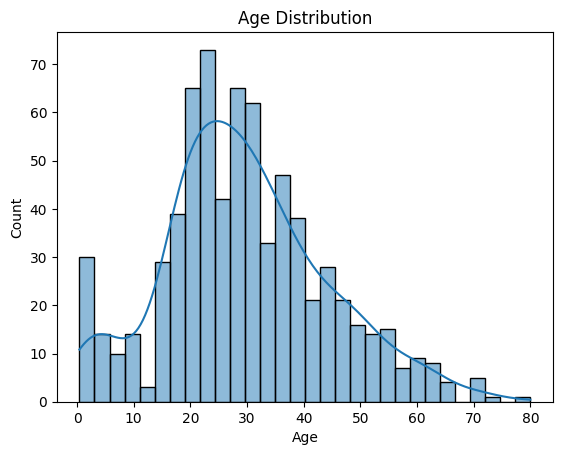

In [50]:
# Age Distribution

sns.histplot(train_data['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

**Interpretasi cell diatas**:  
Distribusi histogram umur mendekati kurva normal namus sedikit miring ke kanan(right-skewed), dengan konsentrasi penumpang terbesar berada diusia produktif(20-40 tahun).

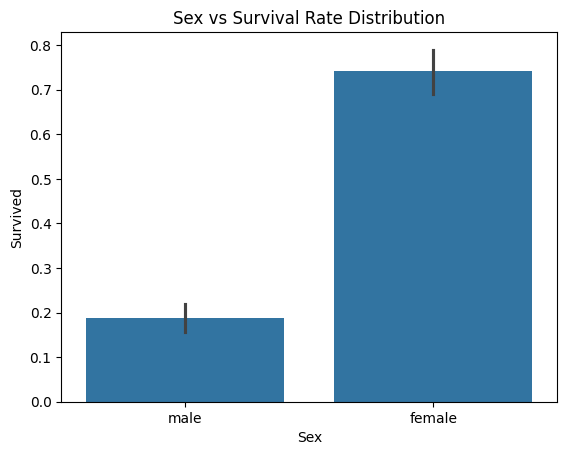

In [51]:
# Sex vs Survival Rate Distribution
sns.barplot(x='Sex', y='Survived', data=train_data)
plt.title('Sex vs Survival Rate Distribution')
plt.show()

**Interpretasi cell diatas**:  
Terdapat perbedaan drastis pada tingkat keselamatan. Perempuan memiliki peluang selamat yang jauh lebih tinggi dibandingkan laki-laki. Ini membuktikan juga aturan wanita didahulukan saat evakuasi.

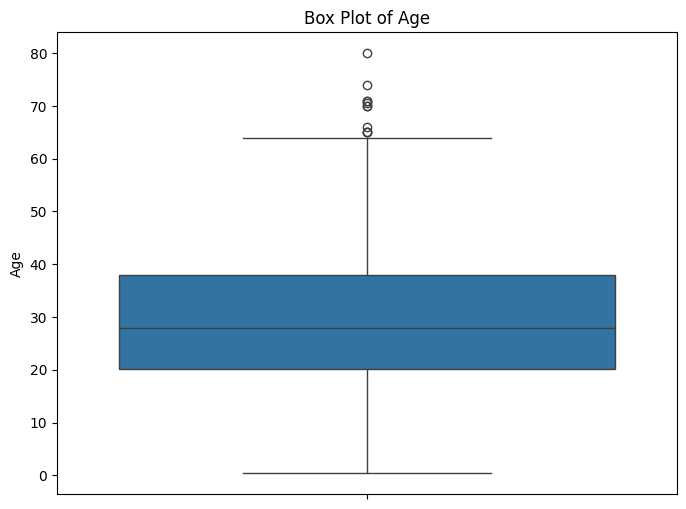

In [52]:
# Box Plot Age

plt.figure(figsize=(8, 6))
sns.boxplot(y=train_data['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

**Interpretasi cell diatas**:  
Terdapat beberapa outlier pada fitur umur (age) menunjukan bahwa ada beberapa data unik yaitu ada lansia dengan umur diatas 65 tahun yang menaiki kapal titanic ini

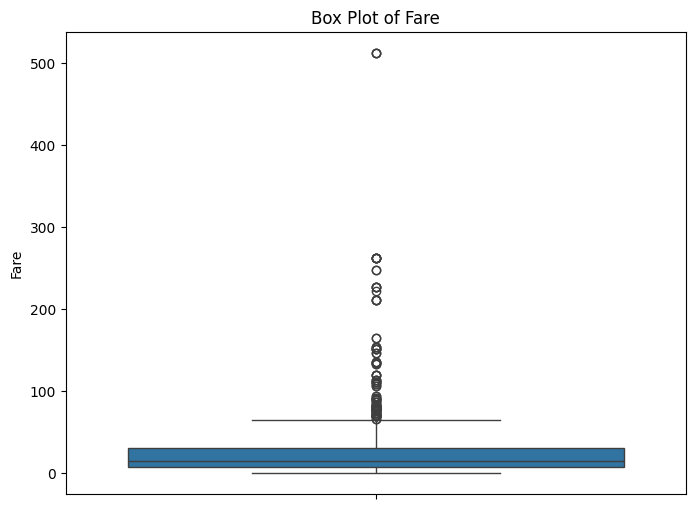

In [53]:
# Box Plot Fare

plt.figure(figsize=(8, 6))
sns.boxplot(y=train_data['Fare'])
plt.title('Box Plot of Fare')
plt.ylabel('Fare')
plt.show()

**Interpretasi cell diatas**:  
Terdapat beberapa outlier pada fitur tarif(fare) dimana kebanyakan orang mempunyai tarif tiket direntang harga 0 hingga 80, dan ada beberapa orang yang membeli tarif tiket diatas harga 80

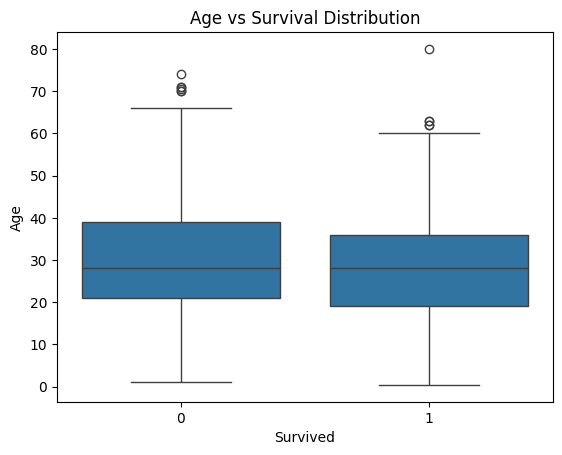

In [54]:
# age vs survived distribution
sns.boxplot(x='Survived', y='Age', data=train_data)
plt.title('Age vs Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Age')
plt.show()

#### Interpretasi cell diatas :
Rentang umur pada kedua kelompok (selamat/tidak selamat) serupa. Namun, pada kelompok selamat, terdapat variasi umur yang lebih lebar di bagian bawah (anak-anak), menunjukkan prioritas keselamatan pada usia muda. lalu kita bisa lihat juga di boxplot terdapat beberapa outlier yang keluar

In [55]:
# Correlation-Based Feature Selection

import numpy as np
numerical_cols = train_data.select_dtypes(include=[np.number]).columns
corr = train_data[numerical_cols].corr()
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


**Interpretasi cell diatas**:  
Melihat beberapa corelasi antar fitur menggunakan tabel dan cukup sulit dibaca

In [56]:
# Creating an Interactive Heatmap

import plotly.express as px
fig = px.imshow(corr, text_auto='.2f', aspect='auto', color_continuous_scale='RdBu_r', title='Interactive Correlation Matrix')

fig.update_layout(width=800, height=700)
fig.show()

**Interpretasi cell diatas**:  
Melihat beberapa korelasi antar fitur menggunakan heatmap dimana kita bisa melihat dengan jelas secara detail juga korelasi antar fiturnya seperti tarif(fare) dan kelas penumpang(pclass) memiliki korelasi tinggi bertolak belakang atau minus

In [57]:
# Top Correlated Features with 'Survived'

top_corr = corr['Survived'].abs().sort_values(ascending=False).head(6)
top_corr

Survived    1.000000
Pclass      0.338481
Fare        0.257307
Parch       0.081629
Age         0.077221
SibSp       0.035322
Name: Survived, dtype: float64

**Interpretasi cell diatas**:<br>
Top fitur secara ascending yang berkorelasi dengan fitur target(Survived)

# Data Preprocessing

In [58]:
# Drop Column with 50% Missing Values

missing_ratio = train_data.isnull().mean()
cols_to_keep = missing_ratio[missing_ratio <= 0.5].index
train_data = train_data[cols_to_keep]
train_data.shape

(891, 8)

**Interpretasi cell diatas**:<br>
Menghapus fitur/kolom yang mempunyai missing value diatas 50%, namun karena di dataset ini yang mempunyai missing value terbanyak hanya 19.87% jadi tidak ada yang terkena drop missing value code ini

In [59]:
# Age Imputation with Mean

train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())

**Interpretasi cell diatas**:<br>
Mengisi missing value variable umur(Age) menggunakan rata-rata(Mean) karena umur adalah data numerik yang distribusi nya cukup padat

In [60]:
# Embarked with Mode

train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

**Interpretasi cell diatas**:<br>
Mengisi missing value variable Pelabuhan Keberangkatan(Embarked) karena hanya 2 data hilang ktia menggunakan modus karena umur adalah data kategorikal, maka diisi dengan nilai yang paling sering muncul.

In [61]:
# Re check Missing Values

missing_summary = pd.DataFrame({
    'Missing Count': train_data.isnull().sum(),
    'Missing Percentage(%)': (train_data.isnull().mean() * 100).round(2)
})
missing_summary

,Missing Count,Missing Percentage(%)
Survived,0,0.0
Pclass,0,0.0
Sex,0,0.0
Age,0,0.0
SibSp,0,0.0
Parch,0,0.0
Fare,0,0.0
Embarked,0,0.0


**Interpretasi cell diatas**:<br>
Setelah proses mengisi missing value bisa dilihat sekarang sudah tidak ada lagi data yang hilang atau tidak terisi

In [62]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in ['Sex', 'Embarked']:
    train_data[col] = le.fit_transform(train_data[col])

**Interpretasi cell diatas**:<br>
Mengubah data kategorikal menjadi angka agar bisa dibaca algoritma dan komputer, dimana contoh: (Male/Female) menjadi 0 dan 1

In [63]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


**Interpretasi cell diatas**:<br>
Konfirmasi data kategorikal sudah berubah menjadi numerical yang sudah bisa dibaca oleh komputer

In [64]:
# Seperate Target Class

x = train_data.drop('Survived', axis=1)
y = train_data['Survived']

**Interpretasi cell diatas**:<br>
Memisahkan fitur dependen(y) dan independen(x) lalu mendeklarasikannya di variable baru

In [65]:
# Split dataset into training and testing 70:30

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

**Interpretasi cell diatas**:  
Membagi data Training (Data latih) dan data Validation (Data Validasi) dengan rasio 70:30 dan diacak secara konsisten dan juga mengelompokan sesuai bobot kelasnya agar tidak imbalance class

In [66]:
# Normalization with Standard Scaler

from sklearn.preprocessing import StandardScaler

scale_cols = ['Age', 'Fare']

scaler = StandardScaler()

x_train[scale_cols] = scaler.fit_transform(x_train[scale_cols])
x_test[scale_cols] = scaler.transform(x_test[scale_cols])

**Interpretasi cell diatas**: 
transformasi atau standarisasi kolom umur(age) dan tarif(fare) memiliki skala yang sangat tinggi dengan data yang lainnya dan standarisasi mengubah data sehingga memiliki rata-rata = 0 dan standar deviasi = 1, lalu standar scaler(z-score) ini memiliki rentang dari -1 hingga 1

In [67]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
748,1,1,-0.842505,1,0,0.465738,2
45,3,1,-0.021501,0,0,-0.478269,2
28,3,0,-0.021501,0,0,-0.481848,1
633,1,1,-0.021501,0,0,-0.646954,2
403,3,1,-0.151884,1,0,-0.314823,2


**Interpretasi cell diatas**: 
hasil transformasi atau standarisasi variable umur(age) dan tarif(fare) supaya rentang nya sama

# Model Deployment & Development

In [68]:
# Support Vector Machine
from sklearn.svm import SVC

model_svm = SVC(
    kernel='rbf', # Radial Basis Function untuk data non-linear
    C=10, # Regularisasi lebih ketat → fit lebih baik ke training
    gamma='scale', # Otomatis: 1 / (n_features × Var(X))
    probability=True, # Aktifkan probabilitas untuk ROC-AUC
    class_weight='balanced',
    random_state=42
)
model_svm.fit(x_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


**Interpretasi cell diatas**:
Mengimport model Support Vector Machine (SVM), algoritma mencari hyperplane dengan margin terbesar yang memisahkan dua kelas (selamat vs tidak selamat). Pada data yang tidak dapat dipisahkan secara linear, SVM menggunakan kernel trick untuk memetakan data ke dimensi lebih tinggi.

In [69]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
model_lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


**Interpretasi cell diatas**:
Mengimport model Logistic Regression dengan memodelkan probabilitas setiap penumpang selamat menggunakan fungsi sigmoid yang mengubah output linear menjadi nilai antara 0 dan 1. Jika probabilitas > 0.5, prediksi = selamat.

In [70]:
# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(
    n_neighbors=5, # 5 Tetangga terdekat untuk voting class
    weights='distance', # Tetangga lebih dekat = pengaruh lebih besar
    metric='euclidean', # Mengukur jarak dengan rumus euclidean
    n_jobs=-1
)
model_knn.fit(x_train, y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,-1


**Interpretasi cell diatas**:
Mengimport model K-Nearest Neighbors (KNN) dimana KNN adalah algoritma model bertipe lazy learner — tidak membangun model saat training. Saat prediksi, KNN mencari 5 data training terdekat dan mengklasifikasikan berdasarkan mayoritas kelas tetangga tersebut. Normalisasi (StandardScaler) sangat penting agar jarak antar fitur tidak didominasi oleh skala fitur tertentu.

In [71]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    max_depth=5, # Batas kedalaman pohon agar tidak overfit
    min_samples_split=20, # Minimal data untuk split node
    min_samples_leaf=10, # Minimal data di setiap daun pohon
    class_weight='balanced',
    random_state=42
)
model_dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


**Interpretasi cell diatas**:
Mengimport model Decision Tree dimana algoritma ini akan membangun struktur pohon keputusan dengan membagi data berdasarkan fitur yang paling informatif (kriteria Gini impurity). Setiap node merupakan kondisi pemisah, dan setiap daun adalah prediksi kelas akhir.

In [72]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300, # Jumlah pohon dalam hutan
    max_depth=10, # Kedalaman maksimum setiap pohon
    max_features='sqrt', # Fitur yang dipertimbangkan per split
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(x_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Interpretasi cell diatas**:
Random Forest adalah algoritma ensemble yang melatih banyak Decision Tree secara paralel, masing-masing pada subset data (bootstrap) dan subset fitur yang acak, lalu menggabungkan prediksi mereka dengan majority voting.

# Model Evaluation

In [73]:
# Evaluasi semua model dengan 5 metrik
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

models_q5 = {
    'SVM': model_svm,
    'Logistic Regression': model_lr,
    'KNN': model_knn,
    'Decision Tree': model_dt,
    'Random Forest': model_rf,
}

results_q5 = []
for name, model in models_q5.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]
    results_q5.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    })

df_q5 = pd.DataFrame(results_q5).set_index('Model')
df_q5

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
SVM,0.8097,0.7453,0.7670,0.7560,0.8364
Logistic Regression,0.8022,0.7155,0.8058,0.7580,0.8513
KNN,0.7799,0.7157,0.7087,0.7122,0.8135
Decision Tree,0.7985,0.7526,0.7087,0.7300,0.8490
Random Forest,0.8097,0.7549,0.7476,0.7512,0.8628


**Interpretasi cell diatas**:
Tabel perbandingan performa 5 model berbeda pada 267 data testing:

Penjelasan metrik:
- Accuracy: Proporsi prediksi benar secara keseluruhan — SVM dan Random Forest sama-sama tertinggi (80.97%).
- Precision: Dari yang diprediksi selamat, berapa persen yang benar-benar selamat — Random Forest tertinggi (75.49%).
- Recall: Dari yang benar-benar selamat, berapa persen yang terdeteksi — Logistic Regression tertinggi (80.58%).
- F1-Score: Keseimbangan Precision dan Recall — Logistic Regression terbaik (75.80%).
- ROC-AUC: Kemampuan diskriminasi keseluruhan — Random Forest terbaik (86.28%).

SVM dengan C=10 meningkatkan Accuracy dari 80.22% (C=1) menjadi 80.97% dan F1-Score dari 74.40% menjadi 75.60%, menyamai akurasi Random Forest.

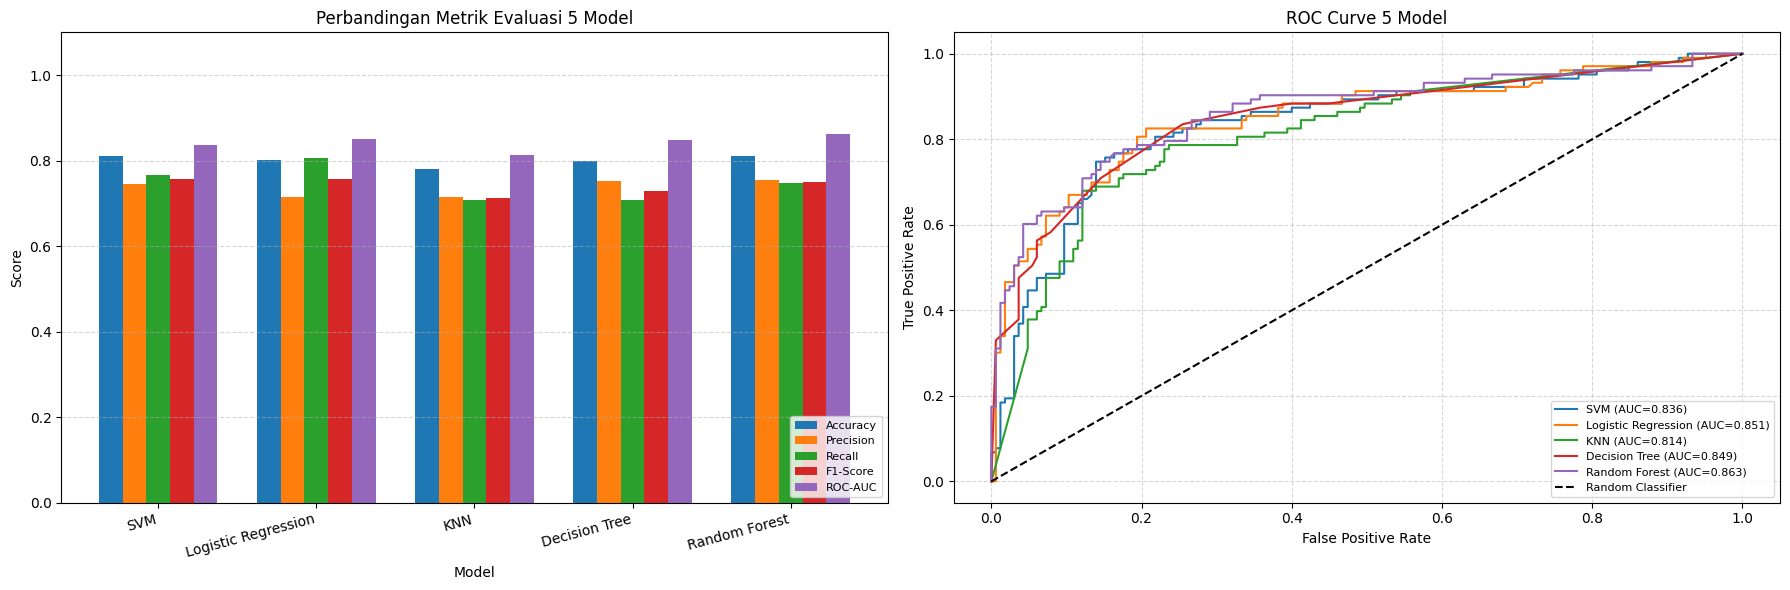

In [74]:
# Visualisasi perbandingan metrik dan ROC Curve
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
mod_names = df_q5.index.tolist()
x_pos     = np.arange(len(mod_names))
width     = 0.15

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
ax = axes[0]
for i, metric in enumerate(metrics):
    ax.bar(x_pos + i * width, df_q5[metric], width, label=metric)
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Evaluasi 5 Model')
ax.set_xticks(x_pos + width * 2)
ax.set_xticklabels(mod_names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# ROC Curve
ax2 = axes[1]
for name, model in models_q5.items():
    y_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax2.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve 5 Model')
ax2.legend(loc='lower right', fontsize=8)
ax2.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

**Bar Chart (kiri)**: SVM dan Random Forest memiliki batang Accuracy tertinggi (setara). Logistic Regression unggul di Recall dan F1-Score. KNN tampil paling rendah secara konsisten di hampir semua metrik.

**ROC Curve (kanan)**: Kurva mendekati sudut kiri atas = model semakin baik. Semua model berada di atas garis diagonal (random classifier), menunjukkan kemampuan prediksi yang bermakna. Random Forest memiliki AUC tertinggi (0.863), sedangkan SVM berada di urutan ke-4 (AUC=0.836). Meskipun SVM unggul di Accuracy, AUC-nya lebih rendah karena SVM lebih agresif dalam menentukan threshold dibanding model probabilistik seperti LR dan RF.

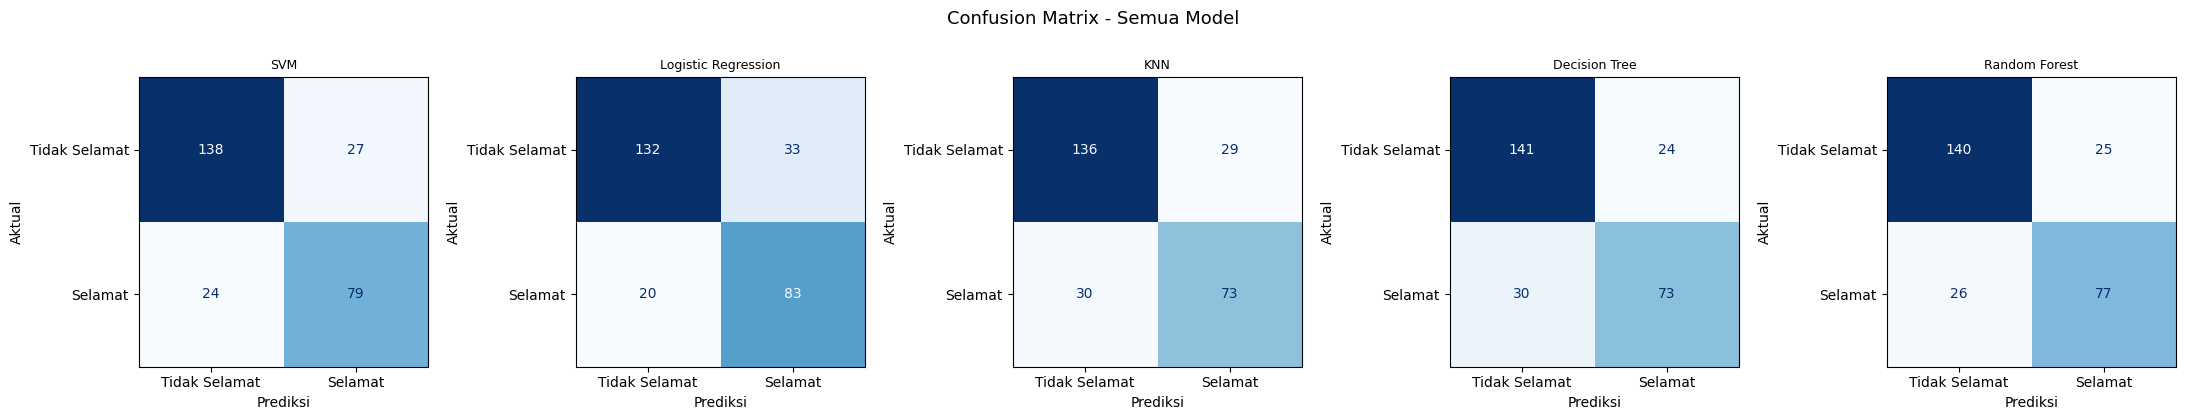

In [75]:
# Confusion Matrix semua model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, model) in zip(axes, models_q5.items()):
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Tidak Selamat', 'Selamat'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix - Semua Model', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:
Confusion Matrix menampilkan detail prediksi setiap model. Data uji terdiri dari beberapa model:

SVM memiliki FN=24, lebih baik dari Decision Tree (FN=30) dan KNN (FN=30), menunjukkan SVM lebih baik dalam mendeteksi penumpang yang benar-benar selamat.

# Comparative Analysis

=== Model Terbaik per Metrik ===
Best Accuracy  : SVM                       (0.8097)
Best Precision : Random Forest             (0.7549)
Best Recall    : Logistic Regression       (0.8058)
Best F1-Score  : Logistic Regression       (0.7580)
Best ROC-AUC   : Random Forest             (0.8628)

=== Tabel Evaluasi (diurutkan berdasarkan F1-Score) ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8022     0.7155  0.8058    0.7580   0.8513
SVM                    0.8097     0.7453  0.7670    0.7560   0.8364
Random Forest          0.8097     0.7549  0.7476    0.7512   0.8628
Decision Tree          0.7985     0.7526  0.7087    0.7300   0.8490
KNN                    0.7799     0.7157  0.7087    0.7122   0.8135


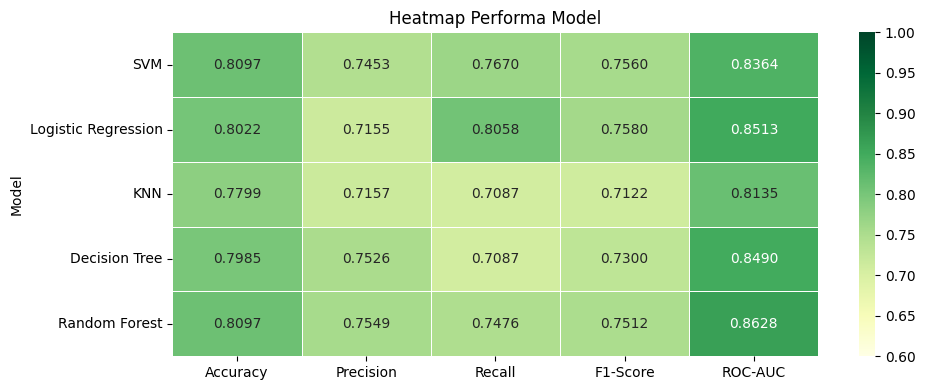

In [76]:
# Perbandingan model terbaik per metrik
best_acc  = df_q5['Accuracy'].idxmax()
best_prec = df_q5['Precision'].idxmax()
best_rec  = df_q5['Recall'].idxmax()
best_f1   = df_q5['F1-Score'].idxmax()
best_auc  = df_q5['ROC-AUC'].idxmax()

print('=== Model Terbaik per Metrik ===')
print(f'Best Accuracy  : {best_acc:<25} ({df_q5.loc[best_acc,  "Accuracy"]:.4f})')
print(f'Best Precision : {best_prec:<25} ({df_q5.loc[best_prec, "Precision"]:.4f})')
print(f'Best Recall    : {best_rec:<25} ({df_q5.loc[best_rec,  "Recall"]:.4f})')
print(f'Best F1-Score  : {best_f1:<25} ({df_q5.loc[best_f1,   "F1-Score"]:.4f})')
print(f'Best ROC-AUC   : {best_auc:<25} ({df_q5.loc[best_auc,  "ROC-AUC"]:.4f})')
print()
print('=== Tabel Evaluasi (diurutkan berdasarkan F1-Score) ===')
print(df_q5.sort_values('F1-Score', ascending=False).to_string())

import seaborn as sns
plt.figure(figsize=(10, 4))
sns.heatmap(df_q5, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, vmin=0.6, vmax=1.0)
plt.title('Heatmap Performa Model')
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:
Output menampilkan peringkat model terbaik per metrik dan heatmap visual performa:

**Model Terbaik per Metrik:**
- **Accuracy**: SVM = Random Forest (0.8097) — keduanya sama-sama tertinggi
- **Precision**: Random Forest (0.7549) — paling sedikit false alarm
- **Recall**: Logistic Regression (0.8058) — paling banyak mendeteksi yang selamat
- **F1-Score**: Logistic Regression (0.7580) — keseimbangan terbaik
- **ROC-AUC**: Random Forest (0.8628) — diskriminasi terbaik di semua threshold

**Heatmap**: Warna hijau tua = nilai lebih tinggi. Baris KNN paling terang (performa terendah secara keseluruhan). SVM, LR, dan RF tampil dengan warna yang relatif sama gelapnya, menunjukkan ketiga model berkompetisi ketat.

## Ringkasan Comparative Analysis


### 1. Model Terbaik: Random Forest

Random Forest adalah model terbaik secara keseluruhan berdasarkan alasan berikut:
1. ROC-AUC tertinggi (86.28%) kemampuan membedakan kelas selamat dan tidak selamat paling baik di semua threshold, metrik paling andal untuk evaluasi klasifikasi biner.
2. Precision tertinggi (75.49%) dari semua yang diprediksi selamat, 75.49% memang benar-benar selamat.
3. Accuracy tertinggi (80.97%) setara dengan SVM.
4. Stabil dan seimbang di semua metrik - tidak ada kelemahan ekstrem di satu metrik tertentu.

Random Forest unggul karena menggabungkan 300 Decision Tree dengan teknik bagging dan random feature selection - setiap pohon belajar dari subset data dan fitur berbeda, sehingga error individual saling mengimbangi (variance reduction).

### 2. Mengapa SVM Lebih Baik dari KNN dan Decision Tree?

- SVM vs KNN: SVM membangun model global (hyperplane) yang tidak bergantung seluruhnya pada jarak ke data training saat prediksi. KNN sangat sensitif terhadap data noise dan tidak memiliki mekanisme regularisasi, sehingga rentan terhadap outlier yang ada di data Titanic (misalnya tarif tiket ekstrem).
- SVM vs Decision Tree: SVM mencari batas keputusan global dengan margin maksimum, sedangkan Decision Tree membuat batas keputusan yang greedy (split terbaik secara lokal) yang lebih mudah overfit meski sudah dibatasi max_depth.

### 3. Kesimpulan

Urutan performa model dari terbaik ke terburuk (berdasarkan ROC-AUC):

Random Forest (0.8628) > Logistic Regression (0.8513) > SVM (0.8364) > Decision Tree (0.8490) > KNN (0.8135)

Catatan: Jika dilihat dari F1-Score: LR > SVM > RF > DT > KNN

Rekomendasi pemilihan model berdasarkan kebutuhan:
- Akurasi & stabilitas keseluruhan : Random Forest
- Meminimalkan penumpang selamat yang terlewat (FN kecil) : Logistic Regression
- Keseimbangan Precision-Recall dengan model yang lebih kuat dari linear : SVM
- Interpretasi mudah oleh non-teknis : Decision Tree